In [1]:
import pandas as pd
data=pd.read_csv(r"C:\Users\sujithra\Downloads\Advertising.csv")
data

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [2]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
data.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [4]:
data.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [5]:
data.dtypes

Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

In [6]:
data.shape

(200, 5)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [8]:
data.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [9]:
data.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

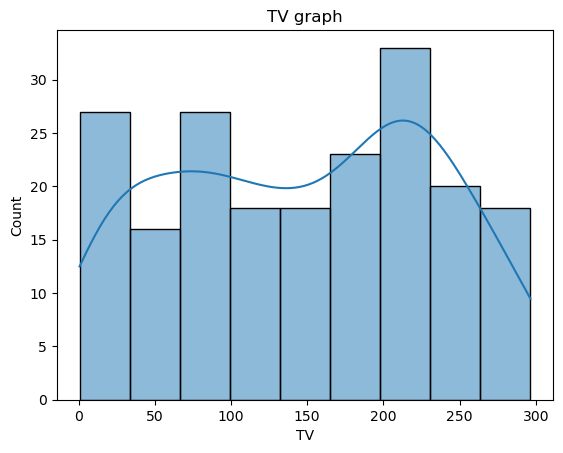

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=data,x='TV',kde=True)
plt.title('TV graph')
plt.show()

INSIGHT:data is not normally distributed

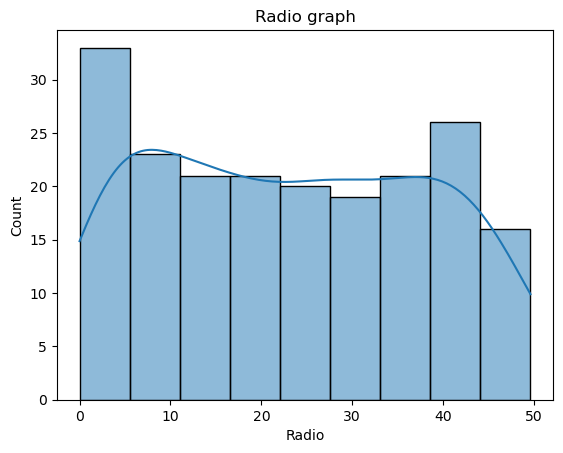

In [12]:
sns.histplot(data=data,x='Radio',kde=True)
plt.title('Radio graph')
plt.show()

INSIGHT:
graph is not normally distributed

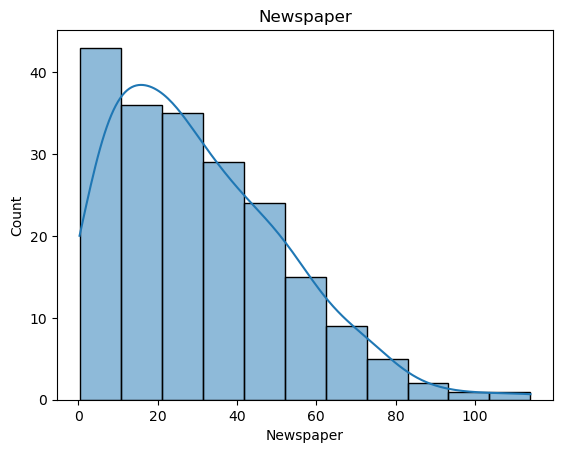

In [13]:
sns.histplot(data=data,x='Newspaper',kde=True)
plt.title('Newspaper')
plt.show()

INSIGHT:
graph is skewed there is a chance to see outlier

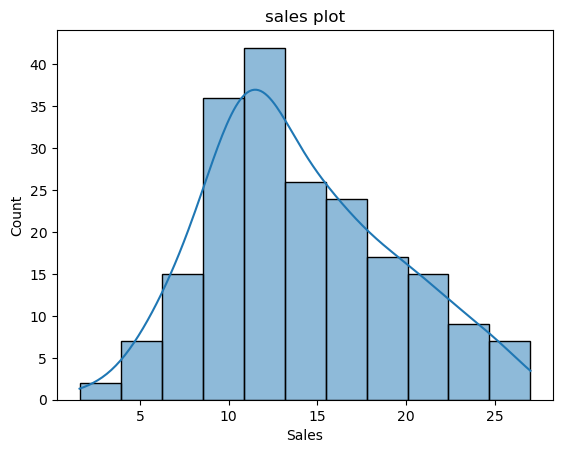

In [14]:
sns.histplot(data=data,x='Sales',kde=True)
plt.title('sales plot')
plt.show()

INSIGHT:approx.normal distribution because the plot is a bell curve graph

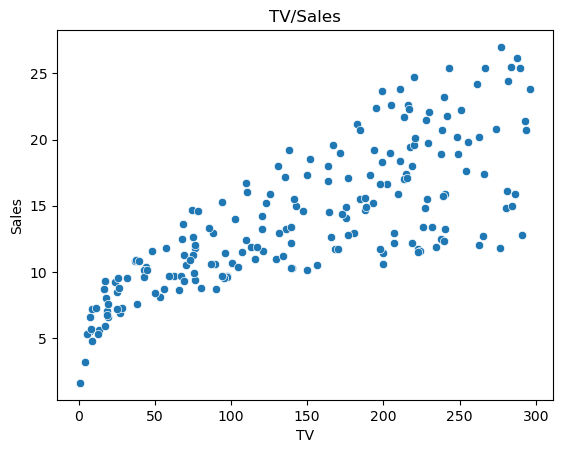

In [15]:
#bivariate analysis
import warnings
warnings.filterwarnings('ignore')
sns.scatterplot(data=data,x='TV',y='Sales')
plt.title('TV/Sales')
plt.show()

INSIGHT:graph is in a positive trend.As the spend of tv increase the sales also increase
radio has a moderately postive trend comapring to tv not much
In the case of newspaper sales is not increasing according to the spend of newspaper
data are randomly scattered
overall tv has the postive trend n directly proportional

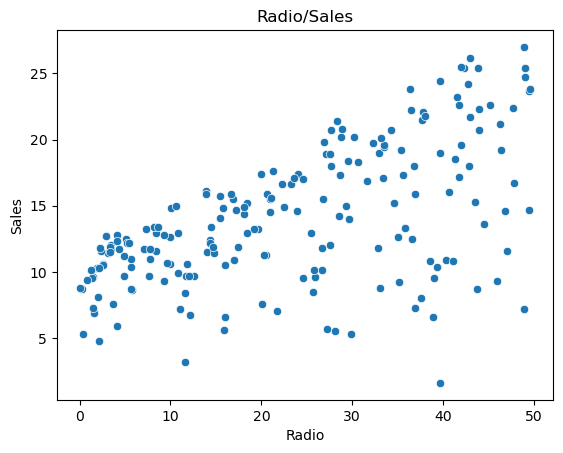

In [16]:
sns.scatterplot(data=data,x='Radio',y='Sales',palette='Set2')
plt.title('Radio/Sales')
plt.show()

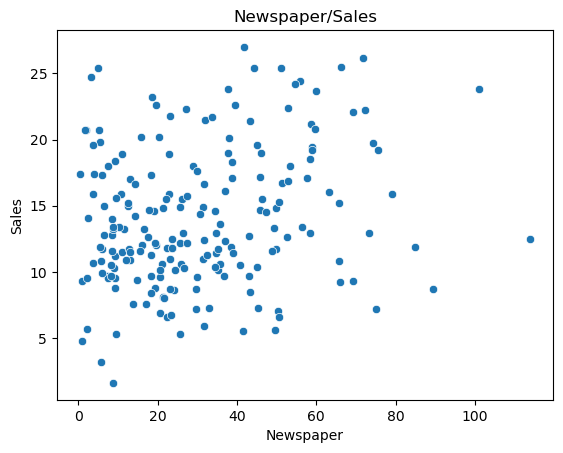

In [17]:
sns.scatterplot(data=data,x='Newspaper',y='Sales',palette='Paired')
plt.title('Newspaper/Sales')
plt.show()

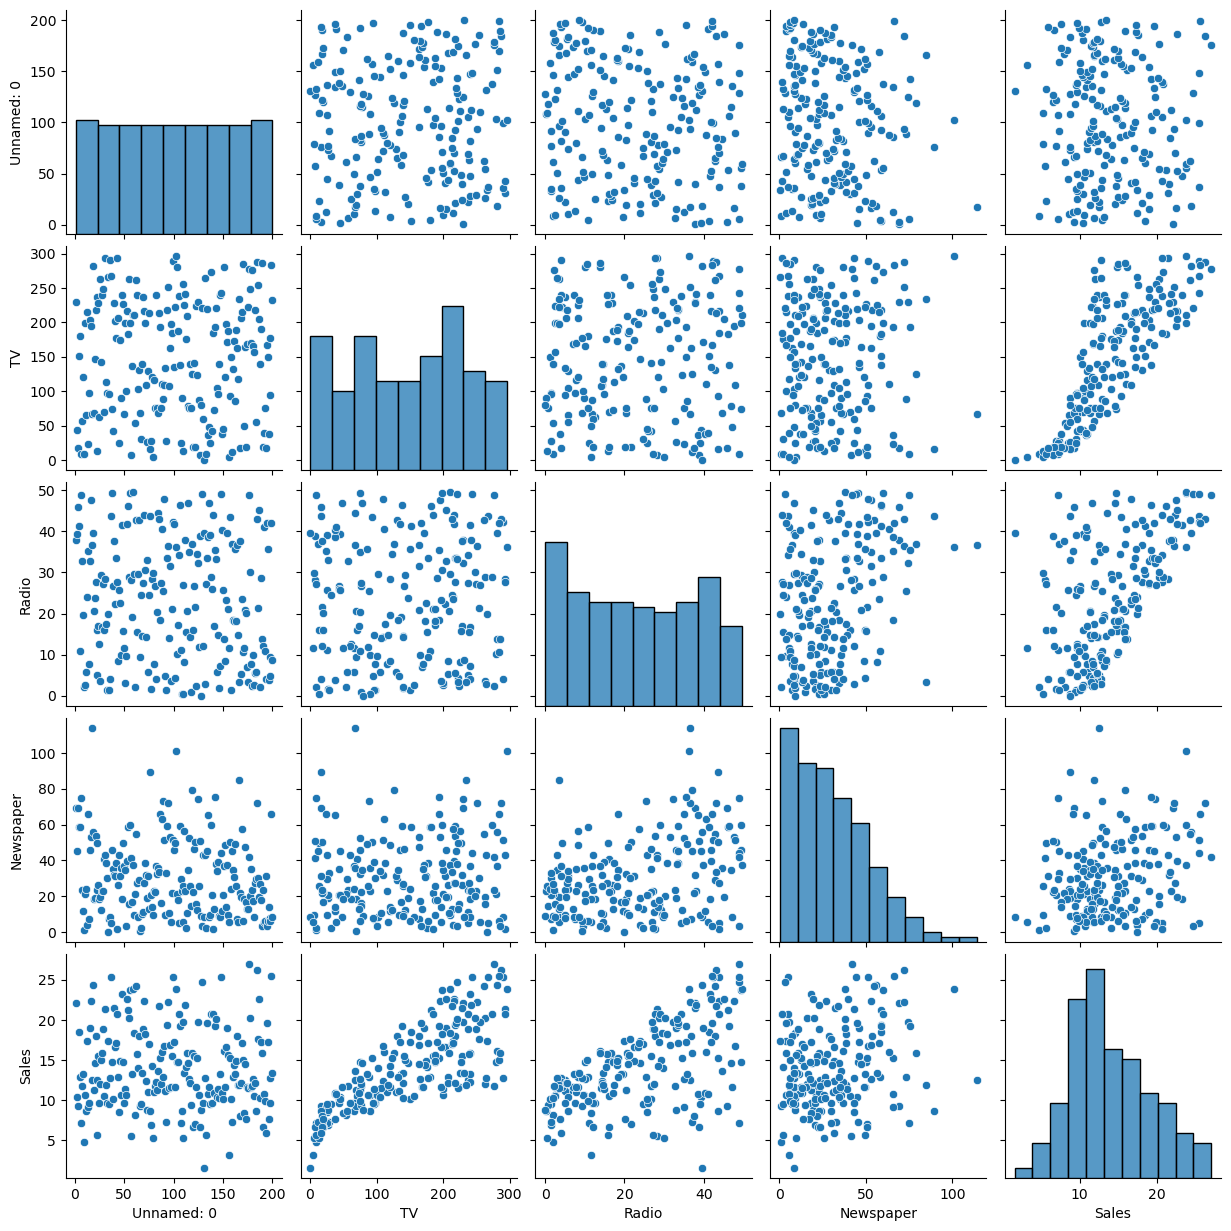

In [18]:
sns.pairplot(data)

Data PreProcessing steps

In [19]:
#check for missing values and handle them
data.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [20]:
#check for duplicates
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='TV'>

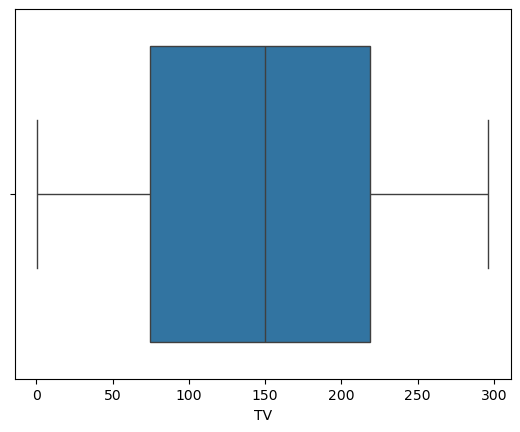

In [21]:
#check for outlier fro tv
sns.boxplot(x=data['TV'])

<Axes: xlabel='Radio'>

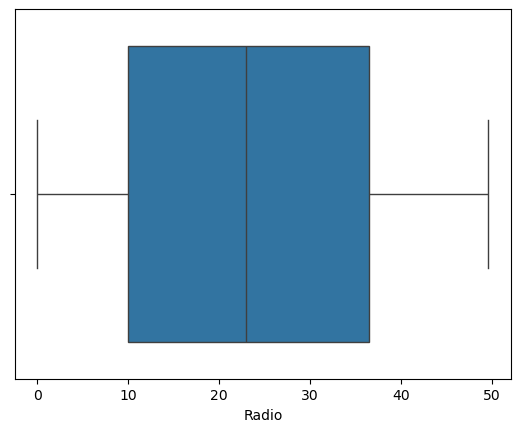

In [15]:
sns.boxplot(x=data['Radio'])

<Axes: xlabel='Newspaper'>

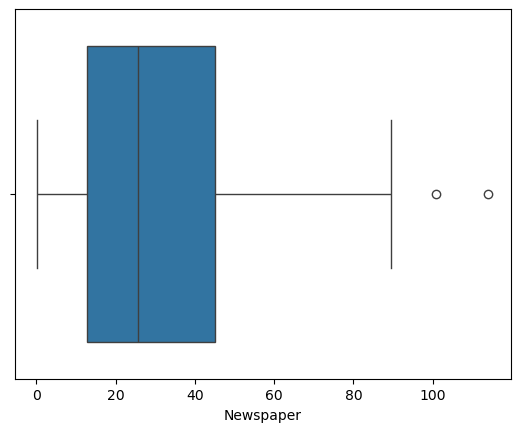

In [16]:
sns.boxplot(x=data['Newspaper'])

<Axes: xlabel='Sales'>

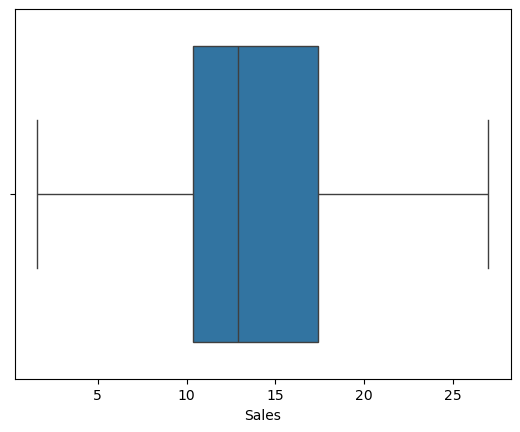

In [17]:
sns.boxplot(x=data['Sales'])

In [22]:
#find Q1 and Q3
Q1=data['Newspaper'].quantile(0.25)
print('lower quartile',Q1)
Q3=data['Newspaper'].quantile(0.75)
print('upper quartile',Q3)
      

lower quartile 12.75
upper quartile 45.1


In [23]:
#find IQR
IQR=Q3-Q1
IQR

np.float64(32.35)

In [24]:
#find lower limit and upperlimit
lower_limit=Q1-1.5*IQR
print('lower_limit',lower_limit)

lower_limit -35.775000000000006


In [25]:
upper_limit=Q3+1.5*IQR
print('upper_limit',upper_limit)

upper_limit 93.625


In [26]:
#find values above upper limit
data.loc[data['Newspaper']>upper_limit]

,Unnamed: 0,TV,Radio,Newspaper,Sales
16,17,67.8,36.6,114.0,12.5
101,102,296.4,36.3,100.9,23.8


In [27]:
len(data.loc[data['Newspaper']>upper_limit])/len(data)

0.01

In [28]:
#replace outliers with median
data.loc[data['Newspaper']>upper_limit,'Newspaper']=data['Newspaper'].median()

<Axes: xlabel='Newspaper'>

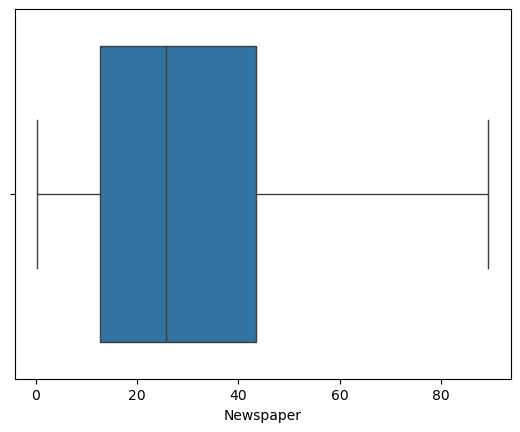

In [29]:
sns.boxplot(x=data.Newspaper)

In [30]:
#feature engineering
data.corr()

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.134882,-0.051616
TV,0.017715,1.000000,0.054809,0.048462,0.782224
Radio,-0.110680,0.054809,1.000000,0.343141,0.576223
Newspaper,-0.134882,0.048462,0.343141,1.000000,0.215938
Sales,-0.051616,0.782224,0.576223,0.215938,1.000000


<Axes: >

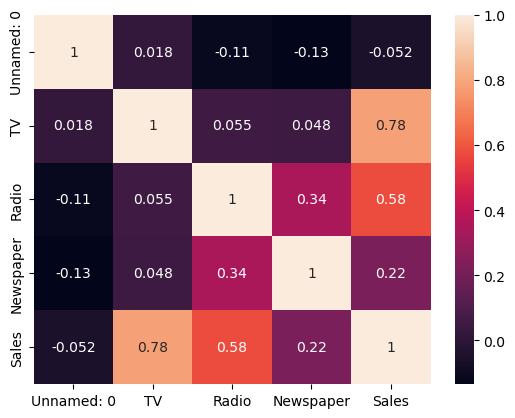

In [31]:
sns.heatmap(data.corr(),annot=True)

<Axes: >

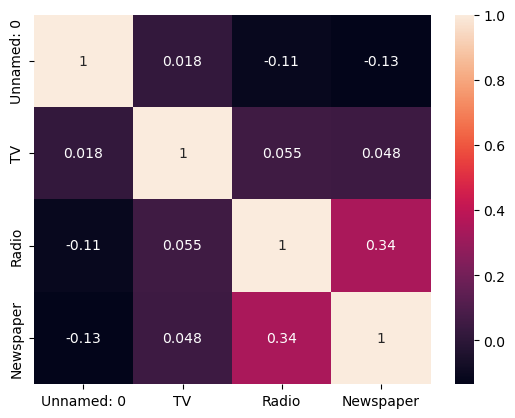

In [33]:
# check for multicollinearity - there should not be any high correlation among input variables.

sns.heatmap(data.drop('Sales',axis=1).corr(),annot=True)

In [34]:
            #split data into x and y

x=data.drop('Sales',axis=1)   # data[['newspaper','radio','tv']]
y=data['Sales']

In [35]:
x

,Unnamed: 0,TV,Radio,Newspaper
0,1,230.1,37.8,69.2
1,2,44.5,39.3,45.1
2,3,17.2,45.9,69.3
3,4,151.5,41.3,58.5
4,5,180.8,10.8,58.4
...,...,...,...,...
195,196,38.2,3.7,13.8
196,197,94.2,4.9,8.1
197,198,177.0,9.3,6.4
198,199,283.6,42.0,66.2


In [36]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

In [45]:
x.drop('Unnamed: 0',axis=1,inplace=True)

In [ ]:
https://scikit-learn.org/stable/index.html

In [46]:
# split data for training and testing.
#sklearn

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=4)

In [47]:
x_train.shape

(140, 3)

In [48]:
x_test.shape

(60, 3)

In [49]:
y_train.shape

(140,)

In [50]:
y_test.shape

(60,)

In [53]:
    # model building

#import linear regression model

from sklearn.linear_model import LinearRegression

#initialise model

model=LinearRegression()

#train model with x_train and y_train

model.fit(x_train,y_train)

LinearRegression()